# 03 · FinBERT on the full TCS corpus (2020 → Mar 2026) — does the signal relate to the stock?

Every TCS-relevant article (3,638) was scored by **A** (off-the-shelf FinBERT, full headline) and **C** (FinBERT-IN, target-aware input).
Per article: `s = P(pos) − P(neg)` ∈ [−1, 1]. Daily features follow the timing rule *news dated d → row t = last trading day ≤ d*, used to predict day t+1.

Questions
1. How do A and C read the corpus differently, and how saturated are their scores?
2. **Direction**: does sentiment on day t relate to the return on t (describing) or t+1 (predicting)?
3. **Magnitude**: does how charged the news is relate to next-day volatility — beyond simply *how much* news there is?
4. **Results days**: does the tone of results coverage line up with the reaction?
5. The ladder recap: what each rung adds out of sample.

Everything in §2–4 is **descriptive, full-sample** (2020–26). The only out-of-sample evidence is the ladder (§5, `model/run_ladder.py`).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from pathlib import Path
from scipy import stats
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
F = ROOT / "data" / "features"
art = pd.read_csv(F / "articles_tcs.csv", parse_dates=["date"])
px = pd.read_csv(F / "price_features_tcs.csv", parse_dates=["date"]).set_index("date")
att = pd.read_csv(F / "news_daily_tcs.csv", parse_dates=["date"]).set_index("date")
day = {m: pd.read_csv(F / f"news_daily_tcs_{m}.csv", parse_dates=["date"]).set_index("date") for m in "AC"}
px["ret_next"] = px["ret"].shift(-1); px["lrv_next"] = np.log(px["rv_target"])
last_news = art.date.max()
print(f"articles {len(art)}  {art.date.min().date()} → {last_news.date()}  | trading days {len(px)} | days with news {(att.n_articles > 0).sum()}")
art.groupby([art.date.dt.year, "role"]).size().unstack(fill_value=0)

articles 3638  2020-01-01 → 2026-03-30  | trading days 1671 | days with news 1115


role,co_mention,list_member,peripheral,primary
date,,,,
2020,45,119,229,201
2021,40,92,215,148
2022,38,125,198,159
2023,82,116,305,179
2024,58,98,246,143
2025,67,126,200,257
2026,30,45,35,42


## 1 · How A and C read the corpus

In [2]:
def cls(s, thr=0.5): return np.where(s > thr, "positive", np.where(s < -thr, "negative", "neutral"))
art["cls_A"], art["cls_C"] = cls(art.sent_A), cls(art.sent_C)
print("label shares (|s| > 0.5 = polar):")
print(pd.DataFrame({m: pd.Series(art[f"cls_{m}"]).value_counts(normalize=True) for m in "AC"}).round(3))
print(f"\nPearson r(A, C) = {art.sent_A.corr(art.sent_C):.3f};  sign disagreement on polar articles: "
      f"{np.mean((art.cls_A != art.cls_C) & (art.cls_A != 'neutral') & (art.cls_C != 'neutral')):.1%}")
pd.crosstab(art.cls_A, art.cls_C, margins=True).rename_axis(index="A", columns="C")

label shares (|s| > 0.5 = polar):
              A      C
negative  0.225  0.241
neutral   0.438  0.377
positive  0.337  0.383

Pearson r(A, C) = 0.806;  sign disagreement on polar articles: 2.4%


C,negative,neutral,positive,All
A,,,,
negative,708,65,46,819
neutral,126,1178,289,1593
positive,41,128,1057,1226
All,875,1371,1392,3638


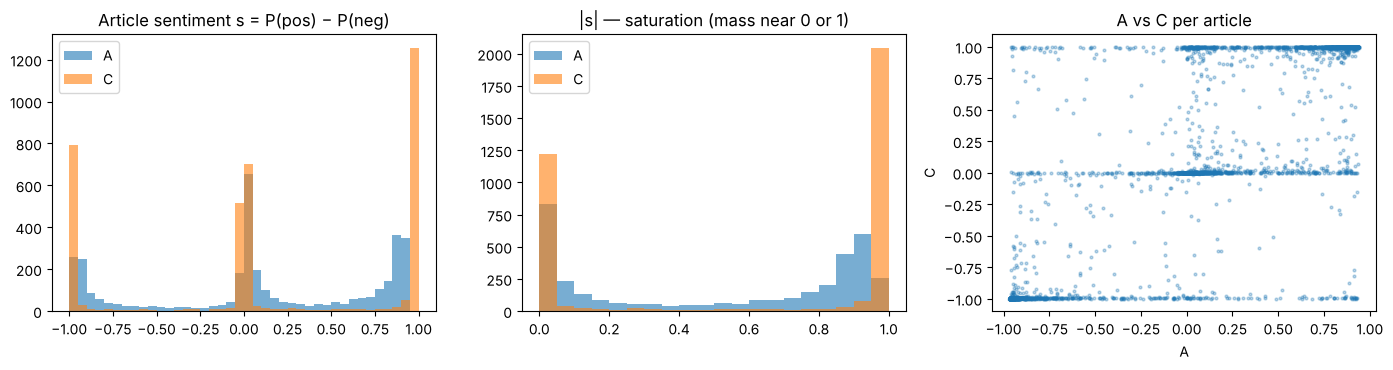

,A,C
|s| > 0.9,0.236,0.585
|s| < 0.1,0.294,0.346
in between,0.470,0.069


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
bins = np.linspace(-1, 1, 41)
for m in "AC": ax[0].hist(art[f"sent_{m}"], bins=bins, alpha=0.6, label=m)
ax[0].set_title("Article sentiment s = P(pos) − P(neg)"); ax[0].legend()
for m in "AC": ax[1].hist(art[f"sent_{m}"].abs(), bins=np.linspace(0, 1, 21), alpha=0.6, label=m)
ax[1].set_title("|s| — saturation (mass near 0 or 1)"); ax[1].legend()
ax[2].scatter(art.sent_A, art.sent_C, s=4, alpha=0.3); ax[2].set_xlabel("A"); ax[2].set_ylabel("C"); ax[2].set_title("A vs C per article")
plt.tight_layout(); plt.show()
sat = pd.DataFrame({m: {"|s| > 0.9": (art[f"sent_{m}"].abs() > 0.9).mean(), "|s| < 0.1": (art[f"sent_{m}"].abs() < 0.1).mean(),
                        "in between": ((art[f"sent_{m}"].abs() >= 0.1) & (art[f"sent_{m}"].abs() <= 0.9)).mean()} for m in "AC"}).round(3)
sat

In [4]:
art.groupby("role")[["sent_A", "sent_C"]].agg(["mean", "std", "count"]).round(3)

sent_A              sent_C             
              mean    std count   mean    std count
role                                               
co_mention   0.157  0.666   360  0.160  0.829   360
list_member  0.057  0.445   721  0.058  0.532   721
peripheral   0.077  0.674  1428  0.129  0.813  1428
primary      0.139  0.688  1129  0.207  0.787  1129

## 2 · Direction — does daily sentiment line up with returns?

`ret_t` = close-to-close return on day t (news *describing* the day's move), `ret_{t+1}` = next day (news *predicting*).
Only days with at least one non-roundup TCS article. HAC (Newey–West, 5 lags) t-stats from `ret ~ sent`.

In [5]:
def hac(y, x, lags=5):
    d = pd.concat([y, x], axis=1).dropna(); r = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1:])).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return r
rows = []
for m in "AC":
    d = day[m].join(px[["ret", "ret_next", "lrv_next", "u_gjr", "rv"]]).join(att[["log_n", "results_day", "n_articles"]], rsuffix="_att")
    d = d[(d.n_articles > d.n_focus) & (d.index <= last_news)]
    for tgt in ["ret", "ret_next"]:
        r = hac(d[tgt], d[["sent"]])
        rows.append({"model": m, "target": tgt, "n days": int(r.nobs), "corr": d["sent"].corr(d[tgt]), "Spearman": stats.spearmanr(d["sent"], d[tgt], nan_policy="omit")[0],
                     "β (ret % per unit s)": r.params["sent"], "HAC t": r.tvalues["sent"], "p": r.pvalues["sent"]})
pd.DataFrame(rows).round(3)

,model,target,n days,corr,Spearman,β (ret % per unit s),HAC t,p
0,A,ret,1082,0.349,0.329,1.006,10.595,0.000
1,A,ret_next,1082,0.027,0.031,0.075,0.928,0.353
2,C,ret,1082,0.369,0.362,0.875,10.766,0.000
3,C,ret_next,1082,0.016,0.020,0.037,0.535,0.592


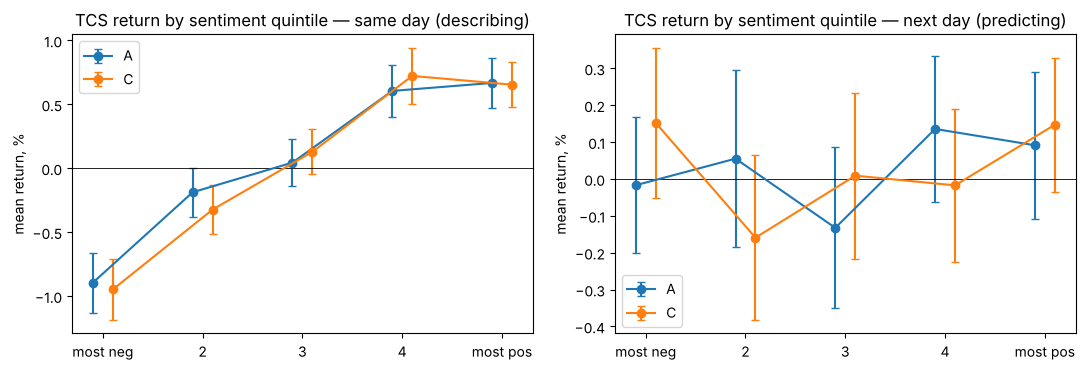

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a_, tgt, ttl in [(ax[0], "ret", "same day (describing)"), (ax[1], "ret_next", "next day (predicting)")]:
    for m in "AC":
        d = day[m].join(px[[tgt]]).join(att[["n_articles"]], rsuffix="_att"); d = d[(d.n_articles > d.n_focus) & (d.index <= last_news)].dropna()
        q = pd.qcut(d["sent"].rank(method="first"), 5, labels=False); g = d.groupby(q)[tgt].agg(["mean", "sem"])
        a_.errorbar(g.index + (0.1 if m == "C" else -0.1), g["mean"], yerr=1.96 * g["sem"], fmt="o-", capsize=3, label=m)
    a_.axhline(0, color="k", lw=0.6); a_.set_xticks(range(5), ["most neg", "2", "3", "4", "most pos"]); a_.set_title(f"TCS return by sentiment quintile — {ttl}")
    a_.set_ylabel("mean return, %"); a_.legend()
plt.tight_layout(); plt.show()

## 3 · Magnitude — does *charged* news mean bigger next-day moves, beyond *how much* news?

Target: `u_{t+1} = ln RV_{t+1} − ln h_{t+1|t}` (what GJR-GARCH misses). If `mag` only proxies attention, its coefficient should vanish once `log_n` and `results_day` are in the regression.

In [7]:
rows = []
for m in "AC":
    d = day[m].join(px[["u_gjr", "lrv_next"]]).join(att[["log_n", "results_day", "n_articles"]], rsuffix="_att")
    d = d[(d.index <= last_news)].dropna(subset=["u_gjr"])
    for spec, cols in [("mag only", ["mag"]), ("attention only", ["log_n", "results_day"]), ("attention + mag", ["log_n", "results_day", "mag"]),
                       ("attention + mag + sent_min", ["log_n", "results_day", "mag", "sent_min"])]:
        X = (d[cols] - d[cols].mean()) / d[cols].std(); r = hac(d["u_gjr"], X)
        rows.append({"model": m, "spec": spec, "n": int(r.nobs), "R²": r.rsquared, **{f"t({c})": r.tvalues[c] for c in cols}})
pd.DataFrame(rows).round(3).fillna("")

,model,spec,n,R²,t(mag),t(log_n),t(results_day),t(sent_min)
0,A,mag only,1044,0.000,0.069,,,
1,A,attention only,1044,0.025,,0.522,4.202,
2,A,attention + mag,1044,0.026,-0.949,0.942,4.015,
3,A,attention + mag + sent_min,1044,0.026,-0.917,0.613,4.007,-1.001
4,C,mag only,1044,0.000,0.352,,,
5,C,attention only,1044,0.025,,0.522,4.202,
6,C,attention + mag,1044,0.025,-0.508,0.716,4.1,
7,C,attention + mag + sent_min,1044,0.026,-0.333,0.357,4.117,-1.037


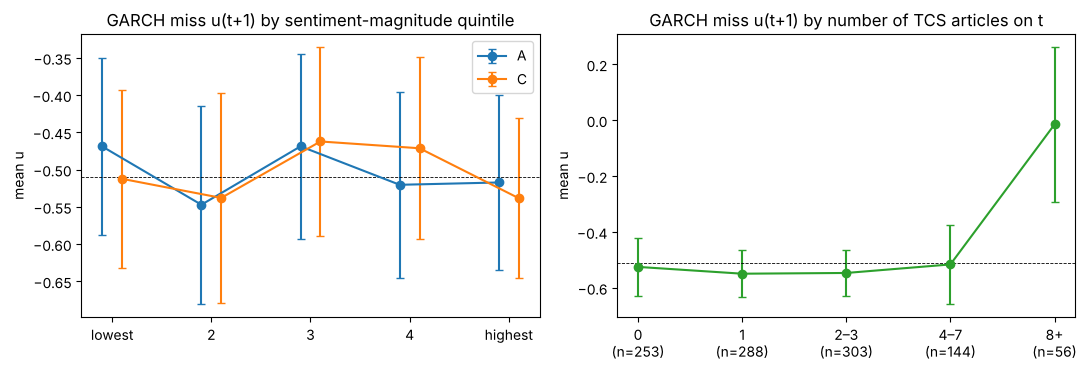

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for m in "AC":
    d = day[m].join(px[["u_gjr"]]).join(att[["n_articles"]], rsuffix="_att"); d = d[(d.n_articles > 0) & (d.index <= last_news)].dropna()
    q = pd.qcut(d["mag"].rank(method="first"), 5, labels=False); g = d.groupby(q)["u_gjr"].agg(["mean", "sem"])
    ax[0].errorbar(g.index + (0.1 if m == "C" else -0.1), g["mean"], yerr=1.96 * g["sem"], fmt="o-", capsize=3, label=m)
d = att.join(px[["u_gjr"]]); d = d[(d.index <= last_news)].dropna()
g = d.groupby(pd.cut(d.n_articles, [-1, 0, 1, 3, 7, 1000], labels=["0", "1", "2–3", "4–7", "8+"]))["u_gjr"].agg(["mean", "sem", "count"])
ax[1].errorbar(range(len(g)), g["mean"], yerr=1.96 * g["sem"], fmt="o-", capsize=3, color="tab:green")
ax[1].set_xticks(range(len(g)), [f"{i}\n(n={c})" for i, c in zip(g.index, g['count'])])
ax[0].set_title("GARCH miss u(t+1) by sentiment-magnitude quintile"); ax[0].set_xticks(range(5), ["lowest", "2", "3", "4", "highest"]); ax[0].legend()
ax[1].set_title("GARCH miss u(t+1) by number of TCS articles on t")
for a_ in ax: a_.axhline(d["u_gjr"].mean(), color="k", lw=0.6, ls="--"); a_.set_ylabel("mean u")
plt.tight_layout(); plt.show()

## 4 · Results days — tone of the coverage vs the reaction

One row per results announcement (first flagged day of each cluster): sentiment of that day's TCS coverage (relevance-weighted, roundups excluded) vs the next session's return and realized volatility.

29 results announcements


,model,feature,target,Spearman ρ,p,n
0,A,sent,ret_next,-0.098,0.615,29
1,A,mag,abs_ret_next,0.133,0.492,29
2,A,mag,u_gjr,0.379,0.090,21
3,C,sent,ret_next,-0.094,0.629,29
4,C,mag,abs_ret_next,0.119,0.538,29
5,C,mag,u_gjr,0.045,0.845,21


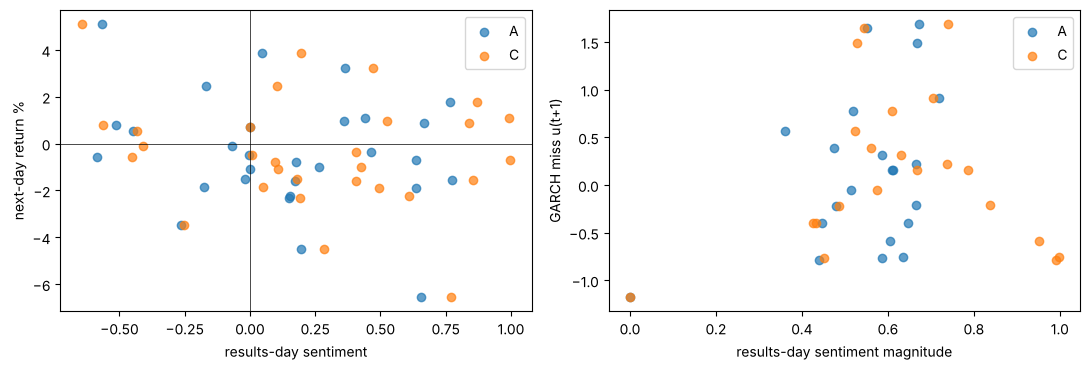

In [9]:
rd = att.index[att.results_day > 0]
first = [t for i, t in enumerate(rd) if i == 0 or (t - rd[i - 1]).days > 5]
ev = pd.DataFrame(index=pd.DatetimeIndex(first))
for m in "AC": ev[f"sent_{m}"] = day[m].loc[ev.index, "sent"]; ev[f"mag_{m}"] = day[m].loc[ev.index, "mag"]
ev = ev.join(px[["ret_next", "rv_target", "u_gjr"]]); ev["abs_ret_next"] = ev.ret_next.abs()
print(f"{len(ev)} results announcements")
rows = []
for m in "AC":
    for tgt in ["ret_next", "abs_ret_next", "u_gjr"]:
        x = ev[f"sent_{m}" if tgt == "ret_next" else f"mag_{m}"]; r = stats.spearmanr(x, ev[tgt], nan_policy="omit")
        rows.append({"model": m, "feature": "sent" if tgt == "ret_next" else "mag", "target": tgt, "Spearman ρ": r[0], "p": r[1], "n": int(ev[tgt].notna().sum())})
display(pd.DataFrame(rows).round(3))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for m, c in [("A", "tab:blue"), ("C", "tab:orange")]:
    ax[0].scatter(ev[f"sent_{m}"], ev.ret_next, label=m, color=c, alpha=0.7); ax[1].scatter(ev[f"mag_{m}"], ev.u_gjr, label=m, color=c, alpha=0.7)
ax[0].set_xlabel("results-day sentiment"); ax[0].set_ylabel("next-day return %"); ax[0].axhline(0, color="k", lw=0.5); ax[0].axvline(0, color="k", lw=0.5)
ax[1].set_xlabel("results-day sentiment magnitude"); ax[1].set_ylabel("GARCH miss u(t+1)")
for a_ in ax: a_.legend()
plt.tight_layout(); plt.show()

### Carry around announcements (C): does the decayed sentiment track the post-results story?

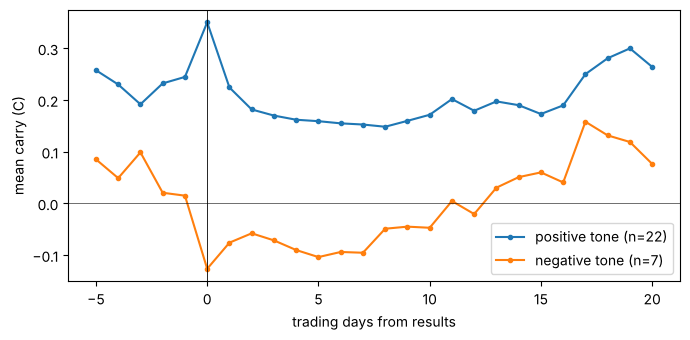

In [10]:
win = range(-5, 21); paths = {"positive tone": [], "negative tone": []}
idx = day["C"].index
for t in ev.index:
    i = idx.get_loc(t); key = "positive tone" if ev.loc[t, "sent_C"] > 0 else "negative tone"
    if i - 5 >= 0 and i + 20 < len(idx): paths[key].append(day["C"]["carry"].values[i - 5:i + 21])
fig, ax = plt.subplots(figsize=(7, 3.5))
for k, v in paths.items():
    if v: ax.plot(list(win), np.mean(v, 0), "o-", ms=3, label=f"{k} (n={len(v)})")
ax.axvline(0, color="k", lw=0.6); ax.axhline(0, color="k", lw=0.4); ax.set_xlabel("trading days from results"); ax.set_ylabel("mean carry (C)"); ax.legend()
plt.tight_layout(); plt.show()

## 5 · Ladder recap — out-of-sample (test: 2024 → Mar 2026)

,all test days,results days,other days
R0 GJR raw,0.4398,0.7784,0.4269
R0c GJR calibrated,0.4551,1.0515,0.4325
R0b +HAR +market,0.4377,1.1183,0.4119
R1 +attention,0.4273,0.5165,0.4240
R2_A +sentiment(A),0.4323,0.5089,0.4294
R2_C +sentiment(C),0.4331,0.5021,0.4305
P1 placebo (shuffled attention),0.4378,1.1252,0.4118


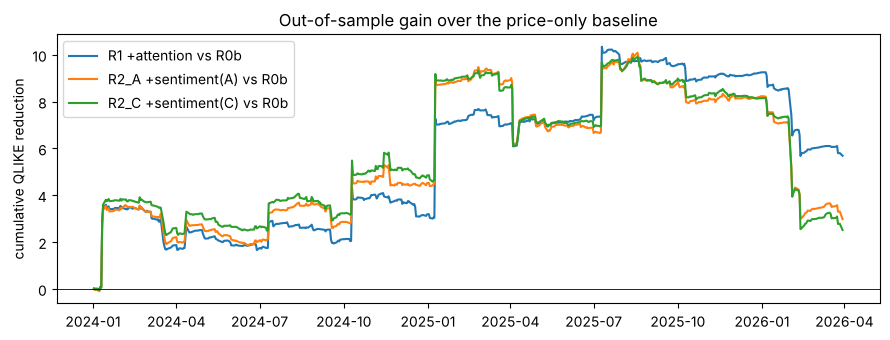

In [11]:
fc = pd.read_csv(ROOT / "results/ladder/forecasts.csv", parse_dates=["date"]).set_index("date")
fc = fc[(fc.index >= "2024-01-01")].dropna()
ql = lambda f: fc.rv_target / fc[f] - np.log(fc.rv_target / fc[f]) - 1
cols = [c for c in fc.columns if c not in ("rv_target", "results_day")]
tab = pd.DataFrame({"all test days": {c: ql(c).mean() for c in cols}, "results days": {c: ql(c)[fc.results_day > 0].mean() for c in cols},
                    "other days": {c: ql(c)[fc.results_day == 0].mean() for c in cols}}).round(4)
display(tab)
fig, ax = plt.subplots(figsize=(9, 3.5))
for c in ["R1 +attention", "R2_A +sentiment(A)", "R2_C +sentiment(C)"]:
    ax.plot((ql("R0b +HAR +market") - ql(c)).cumsum(), label=f"{c} vs R0b")
ax.axhline(0, color="k", lw=0.6); ax.set_ylabel("cumulative QLIKE reduction"); ax.legend(); ax.set_title("Out-of-sample gain over the price-only baseline")
plt.tight_layout(); plt.show()

## 6 · Conclusions

| Question | Answer | Evidence |
|---|---|---|
| Do A and C read the corpus alike? | Mostly — r = 0.81, opposite signs on only 2.4% of polar articles; C calls more articles positive (38% vs 34%) | §1 |
| **Is C's score saturated?** | **Yes**: 58.5% of articles have \|s\| > 0.9 and only 6.9% lie between 0.1 and 0.9 (A: 47% in between) | §1 — the fine-tuned head is over-confident (notebook 02, §5) |
| Does sentiment **describe** the day's move? | **Strongly**: corr with same-day return 0.35 (A) / **0.37 (C)**, HAC t ≈ 10.7 | §2 — FinBERT reads market news correctly |
| Does it **predict** the next day's return? | **No**: corr 0.03 / 0.02, p > 0.35 | §2 — consistent with prices absorbing news the same day |
| Does charged news predict next-day volatility beyond attention? | **No**: t(mag) ≈ −0.5 to −0.9 once `log_n` and `results_day` are in; results-day t ≈ 4.1 | §3 — how much news (and whether it is results) carries the signal |
| Results days (29 announcements) | Tone vs next-day return ρ ≈ −0.1 (n.s.); magnitude vs GARCH miss: A ρ = 0.38 (p = 0.09, n = 21), C ρ = 0.05 | §4 — A's *unsaturated* scores retain a hint of magnitude information that C's saturation erases |
| Out of sample | Attention cuts QLIKE on results days 1.12 → 0.52, but **slightly hurts other days** (0.412 → 0.424); sentiment adds nothing on top | §5 |

**Overall judgment.** Fine-tuned FinBERT-IN is a better *reader* (notebook 02) and its daily sentiment tracks same-day TCS returns closely — a useful descriptive signal. It does not add *forecasting* power for next-day volatility: the timing and volume of news, especially results coverage, do the work, and the fine-tuned model's saturated probabilities leave no usable magnitude signal.

**Next tests (choose on the 2022–23 validation period only — the test period has now been seen):**
1. Temperature-scale C, then retest `mag` — the A-vs-C contrast in §4 suggests calibration is the bottleneck.
2. Restrict news features to results windows (`results_day`, `results_day × mag`), since attention hurts ordinary days.
3. A results *surprise* feature (reported growth vs preview-article expectations), the one text signal theory says should carry magnitude.